# Análisis de datos - Parcial II Comunicaciones

Este cuaderno se ejecuta dentro del contenedor **jupyter** y realiza:

1. Conexión a **PostgreSQL** (`database:5432`) por la red interna `backend_net`.
2. Consulta de tablas del CMS **Joomla** (artículos y registro de actividad).
3. Análisis del **log de tráfico de Nginx** (`trafico.csv`), compartido por volumen.

Ejecute todas las celdas con **Run → Run All Cells**.

In [1]:
import os
import socket
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Datos de conexion: llegan como variables de entorno desde docker-compose / .env
DB_HOST = os.environ.get("DB_HOST", "database")
DB_PORT = int(os.environ.get("DB_PORT", "5432"))
DB_NAME = os.environ["DB_NAME"]
DB_USER = os.environ["DB_USER"]
DB_PASSWORD = os.environ["DB_PASSWORD"]
PREFIJO = os.environ.get("DB_PREFIX", "jml_")
LOG_CSV = "/home/jovyan/logs/trafico.csv"

url = URL.create(
    "postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)
engine = create_engine(url)
print(f"Motor SQLAlchemy listo -> {DB_HOST}:{DB_PORT}/{DB_NAME}")

Motor SQLAlchemy listo -> database:5432/joomla_db


In [2]:
# Resolucion DNS (capa 3): el DNS embebido de Docker traduce "database" a una IP
ip_bd = socket.gethostbyname(DB_HOST)

with engine.connect() as con:
    version = con.execute(text("SELECT version()")).scalar()
    ip_srv, puerto_srv = con.execute(text("SELECT inet_server_addr(), inet_server_port()")).one()
    ip_cli = con.execute(text("SELECT inet_client_addr()")).scalar()

print("Servidor PostgreSQL :", version.split(",")[0])
print(f"DNS  '{DB_HOST}'      -> {ip_bd}")
print(f"Servidor (IP:puerto) -> {ip_srv}:{puerto_srv}  (TCP)")
print(f"Cliente Jupyter      -> {ip_cli}  (backend_net)")

Servidor PostgreSQL : PostgreSQL 16.15 on x86_64-pc-linux-musl
DNS  'database'      -> 172.21.0.2
Servidor (IP:puerto) -> 172.21.0.2:5432  (TCP)
Cliente Jupyter      -> 172.21.0.4  (backend_net)


In [3]:
tablas = pd.read_sql(
    text("""
        SELECT table_name AS tabla
        FROM information_schema.tables
        WHERE table_schema = 'public' AND table_name LIKE :prefijo
        ORDER BY table_name
    """),
    engine,
    params={"prefijo": PREFIJO + "%"},
)
print(f"Joomla creó {len(tablas)} tablas en PostgreSQL con prefijo '{PREFIJO}'")
tablas.head(10)

Joomla creó 76 tablas en PostgreSQL con prefijo 'jml_'


,tabla
0,jml_action_log_config
1,jml_action_logs
2,jml_action_logs_extensions
3,jml_action_logs_users
4,jml_assets
5,jml_associations
6,jml_banner_clients
7,jml_banner_tracks
8,jml_banners
9,jml_categories


In [4]:
articulos = pd.read_sql(
    text(f"""
        SELECT title AS titulo, hits AS visitas
        FROM {PREFIJO}content
        WHERE state = 1
        ORDER BY hits DESC
        LIMIT 10
    """),
    engine,
)

if articulos.empty:
    print("Aún no hay artículos publicados en Joomla.")
else:
    ax = articulos.sort_values("visitas").plot.barh(
        x="titulo", y="visitas", legend=False, figsize=(8, 4), color="#4C72B0"
    )
    ax.set_title("Artículos de Joomla más visitados")
    ax.set_xlabel("Visitas (hits)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

articulos

Aún no hay artículos publicados en Joomla.


,titulo,visitas


Joomla registró 3 acciones de usuarios


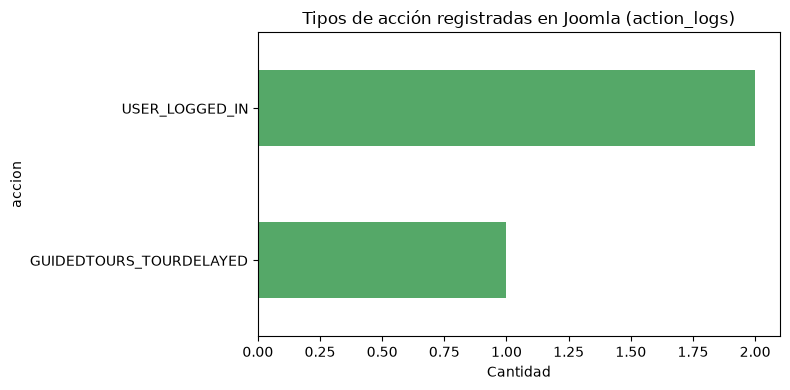

,fecha,extension,accion
0,2026-10-03 05:26:38,com_users,USER_LOGGED_IN
1,2026-10-03 05:26:48,com_guidedtours.state,GUIDEDTOURS_TOURDELAYED
2,2026-10-03 05:32:07,com_users,USER_LOGGED_IN


In [5]:
acciones = pd.read_sql(
    text(f"""
        SELECT log_date AS fecha, extension, message_language_key AS accion
        FROM {PREFIJO}action_logs
        ORDER BY log_date
    """),
    engine,
)

print(f"Joomla registró {len(acciones)} acciones de usuarios")

if not acciones.empty:
    acciones["accion"] = acciones["accion"].str.replace("PLG_ACTIONLOG_JOOMLA_", "", regex=False)
    conteo = acciones["accion"].value_counts().head(10).sort_values()
    ax = conteo.plot.barh(figsize=(8, 4), color="#55A868")
    ax.set_title("Tipos de acción registradas en Joomla (action_logs)")
    ax.set_xlabel("Cantidad")
    plt.tight_layout()
    plt.show()

acciones.tail()

In [6]:
columnas = ["fecha", "ip", "metodo", "uri", "protocolo",
            "codigo", "bytes", "tiempo", "servicio", "user_agent"]

if os.path.exists(LOG_CSV):
    trafico = pd.read_csv(LOG_CSV, names=columnas, header=None, parse_dates=["fecha"])
    print(f"{len(trafico)} peticiones HTTP registradas por Nginx")
else:
    trafico = pd.DataFrame(columns=columnas)
    print("El log aún no existe: navegue por el sitio para generar tráfico.")

trafico.tail()

1623 peticiones HTTP registradas por Nginx


,fecha,ip,metodo,uri,protocolo,codigo,bytes,tiempo,servicio,user_agent
1618,2026-10-03 06:36:39+00:00,172.20.0.1,GET,/jupyter/api/nbconvert?1791009398880,HTTP/1.1,200,620,0.756,jupyter,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:154...
1619,2026-10-03 06:36:39+00:00,172.20.0.1,GET,/jupyter/api/kernelspecs?1791009399654,HTTP/1.1,200,565,0.013,jupyter,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:154...
1620,2026-10-03 06:36:40+00:00,172.20.0.1,PUT,/jupyter/lab/api/workspaces/default?1791009400474,HTTP/1.1,204,0,0.004,jupyter,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:154...
1621,2026-10-03 06:36:43+00:00,172.20.0.1,POST,/jupyter/api/kernels/0d4cbc80-81ea-40f1-8daa-5...,HTTP/1.1,200,158,0.771,jupyter,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:154...
1622,2026-10-03 06:36:43+00:00,172.20.0.1,GET,/jupyter/api/kernels/0d4cbc80-81ea-40f1-8daa-5...,HTTP/1.1,101,28415,3.469,jupyter,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:154...


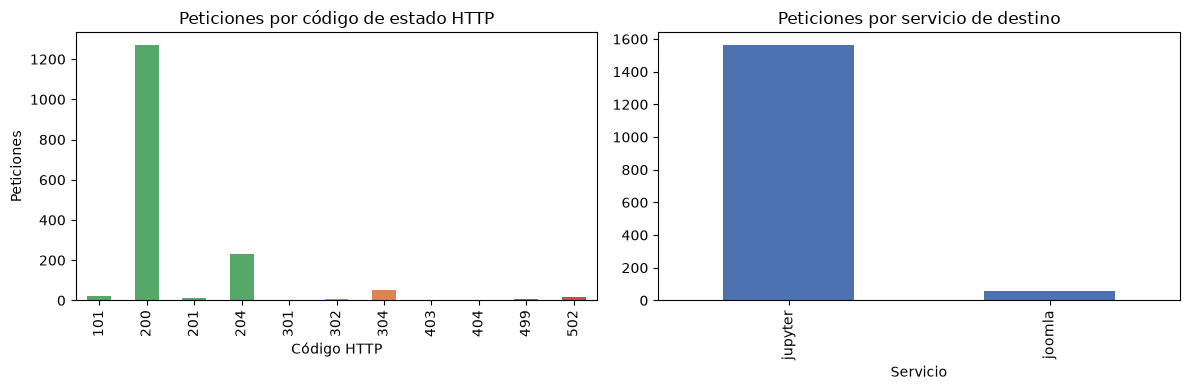

In [7]:
if not trafico.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    codigos = trafico["codigo"].value_counts().sort_index()
    colores = ["#55A868" if c < 300 else "#DD8452" if c < 400 else "#C44E52" for c in codigos.index]
    codigos.plot.bar(ax=ax1, color=colores)
    ax1.set_title("Peticiones por código de estado HTTP")
    ax1.set_xlabel("Código HTTP")
    ax1.set_ylabel("Peticiones")

    trafico["servicio"].value_counts().plot.bar(ax=ax2, color="#4C72B0")
    ax2.set_title("Peticiones por servicio de destino")
    ax2.set_xlabel("Servicio")

    plt.tight_layout()
    plt.show()

In [ ]:
if not trafico.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Intervalo adaptativo: si todo el trafico ocurrio en pocos minutos,
    # se agrupa cada 10 s para que la grafica tenga varios puntos
    duracion = trafico["fecha"].max() - trafico["fecha"].min()
    intervalo = "10s" if duracion < pd.Timedelta(minutes=10) else "1min"
    serie = trafico.set_index("fecha").resample(intervalo).size()

    if len(serie) > 1:
        serie.plot(ax=ax1, marker="o", color="#8172B3")
    else:
        serie.plot.bar(ax=ax1, color="#8172B3")
    ax1.set_title(f"Peticiones por intervalo de {intervalo}")
    ax1.set_ylabel("Peticiones")

    trafico["ip"].value_counts().head(5).sort_values().plot.barh(ax=ax2, color="#937860")
    ax2.set_title("IPs cliente más recurrentes")
    ax2.set_xlabel("Peticiones")

    plt.tight_layout()
    plt.show()

In [9]:
if not trafico.empty:
    resumen = (
        trafico.groupby("servicio")
        .agg(peticiones=("codigo", "size"),
             tiempo_medio_s=("tiempo", "mean"),
             tiempo_max_s=("tiempo", "max"),
             bytes_totales=("bytes", "sum"))
        .round(4)
    )
    display(resumen)

,peticiones,tiempo_medio_s,tiempo_max_s,bytes_totales
servicio,,,,
joomla,60,0.0993,0.175,571507
jupyter,1563,1.9089,1008.214,25346963


## Conclusiones

- La conexión a PostgreSQL se realizó por **nombre de servicio** (`database`), resuelto por el DNS embebido de Docker (127.0.0.11), sobre **TCP 5432** dentro de `backend_net`.
- Joomla persiste su contenido y su registro de actividad en PostgreSQL, por lo que los datos pueden analizarse directamente con SQL.
- Nginx, como único punto de entrada, registra cada petición HTTP. Esto permite analizar códigos de estado, IPs y tiempos de respuesta de todos los servicios.